# CLUE exploration: 2D PCA + uncertainty (Z) + novelty (size)

Three visual channels on top of two-dimensional PCA coordinates, all reflecting the **initial model's perspective**:

| Channel | Quantity | Source |
|---------|----------|---------|
| X / Y   | PC 1 / PC 2 | Joint PCA of run-11 GNN embeddings |
| **Z axis** | **Uncertainty** | Interpolated from run-1 MC-dropout values |
| **Size**   | **Novelty**     | kNN distance from run-1 training distribution |
| **Colour** | **Iteration**   | Which CLUE cycle selected the material (plasma) |

Markers distinguish the three material categories:  
● initial training (run 1) · ◆ CLUE-selected (iterations 1–10) · ▲ remaining target pool

## 1 · Imports and configuration

In [1]:
import numpy             as np
import matplotlib        as mpl
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import torch

from sklearn.decomposition import PCA
from sklearn.neighbors     import NearestNeighbors
from torch_geometric.loader import DataLoader as PyGDataLoader

import libraries.model   as clm
import libraries.dataset as cld

# Verify CUDA is actually usable at runtime
try:
    _dummy = torch.zeros(1).cuda()
    device = torch.device('cuda')
    del _dummy
except Exception:
    device = torch.device('cpu')
print('Device:', device)

# ── Publication style (Nature / Science) ───────────────────────────────────────
mpl.rcParams.update({
    'font.family':        'sans-serif',
    'font.sans-serif':    ['Helvetica', 'Arial', 'DejaVu Sans'],
    'font.size':          9,
    'axes.linewidth':     0.75,
    'axes.labelsize':     10,
    'xtick.labelsize':    8,
    'ytick.labelsize':    8,
    'xtick.major.width':  0.75,
    'ytick.major.width':  0.75,
    'xtick.major.size':   3,
    'ytick.major.size':   3,
    'legend.fontsize':    8,
    'legend.framealpha':  0.85,
    'legend.edgecolor':   '0.8',
    'figure.dpi':         150,
    'savefig.dpi':        300,
    'savefig.bbox':       'tight',
})

# ── Paths ──────────────────────────────────────────────────────────────────────
N_RUNS      = 11
MODEL_RUNS  = [f'models/MP-bandgap-{i}' for i in range(1, N_RUNS + 1)]
TARGET_RUN  = 'targets/MP-bandgap-11'
FINAL_MODEL = MODEL_RUNS[-1]   # run-11: used for embeddings / PCA
FIRST_MODEL = MODEL_RUNS[0]    # run-1:  source of uncertainty & novelty reference

Device: cuda


/home/claudio/cibran/Work/UPC/CLUE/.venv/lib/python3.12/site-packages/torch/cuda/__init__.py:734: UserWarning: Can't initialize NVML
  warnings.warn("Can't initialize NVML")


## 2 · Load run-11 model and reference dataset

The run-11 model provides a well-trained, consistent embedding space for the PCA.
Its reference dataset contains all 7 556 materials seen by the end of the active-learning loop.

In [2]:
ref_dataset_std = torch.load(f'{FINAL_MODEL}/ref_dataset_std.pt', weights_only=False)
r_std_params    = cld.load_json(f'{FINAL_MODEL}/standardized_parameters.json')

print(f'Run-11 reference dataset:  {len(ref_dataset_std):>6} materials')

model11 = clm.load_model(
    ref_dataset_std[0].num_node_features,
    pdropout=0,
    device=device,
    model_name=f'{FINAL_MODEL}/model.pt',
    mode='eval',
)
print('Run-11 model loaded.')

Run-11 reference dataset:    7556 materials
Run-11 model loaded.


## 3 · Identify which materials were promoted in each iteration

In [3]:
def material_key(label: str) -> str:
    """Stable identifier: formula + space-group (first two tokens), ignoring the float part."""
    return ' '.join(label.split()[:2])

run_keys = {}
for i in range(1, N_RUNS + 1):
    d = torch.load(f'models/MP-bandgap-{i}/ref_dataset_std.pt', weights_only=False)
    run_keys[i] = {material_key(g.label) for g in d}

label_to_iter: dict[str, int] = {key: 0 for key in run_keys[1]}

for i in range(1, N_RUNS):
    for key in run_keys[i + 1] - run_keys[i]:
        label_to_iter[key] = i

iter_assignments = np.array(
    [label_to_iter.get(material_key(g.label), -1) for g in ref_dataset_std]
)

for it in range(N_RUNS):
    n = (iter_assignments == it).sum()
    tag = 'initial training' if it == 0 else f'iteration {it}'
    print(f'  {tag}: {n} materials')
print(f'  Unclassified: {(iter_assignments == -1).sum()}')

  initial training: 7456 materials
  iteration 1: 10 materials
  iteration 2: 10 materials
  iteration 3: 10 materials
  iteration 4: 10 materials
  iteration 5: 10 materials
  iteration 6: 10 materials
  iteration 7: 10 materials
  iteration 8: 10 materials
  iteration 9: 10 materials
  iteration 10: 10 materials
  Unclassified: 0


## 4 · Load remaining target pool and re-standardise

In [4]:
target_raw = torch.load(f'{TARGET_RUN}/dataset.pt', weights_only=False)
target_std = cld.standardize_dataset_from_keys(target_raw, r_std_params)
print(f'Remaining target pool: {len(target_std)} materials')

Remaining target pool: 95 materials


## 5 · Extract run-11 embeddings and compute 2-component PCA

All 7 651 materials are embedded with the run-11 model and projected jointly into 2-D PCA space.

In [5]:
def _extract_cpu(dataset, model):
    """Extract 128-dim GNN graph embeddings on CPU (avoids broken CUDA driver)."""
    m = model.module if hasattr(model, 'module') else model
    m = m.cpu().eval()
    parts = []
    with torch.no_grad():
        for batch in PyGDataLoader(dataset, batch_size=128, shuffle=False):
            parts.append(m(batch.cpu(), return_graph_embedding=True).numpy())
    return np.concatenate(parts, axis=0)

print('Extracting run-11 embeddings for training data …')
emb11_ref = _extract_cpu(ref_dataset_std, model11)

print('Extracting run-11 embeddings for target pool …')
emb11_tgt = _extract_cpu(target_std, model11)

# Joint 2-D PCA (fitting on all 7 651 materials)
emb11_all = np.vstack([emb11_ref, emb11_tgt])
pca2      = PCA(n_components=2, random_state=42)
coords2   = pca2.fit_transform(emb11_all)

coords2_ref = coords2[:len(emb11_ref)]
coords2_tgt = coords2[len(emb11_ref):]

evr2 = pca2.explained_variance_ratio_
print(f'\nExplained variance — PC1: {evr2[0]:.1%}  PC2: {evr2[1]:.1%}  '
      f'Total: {evr2.sum():.1%}')

Extracting run-11 embeddings for training data …
Extracting run-11 embeddings for target pool …

Explained variance — PC1: 33.3%  PC2: 20.8%  Total: 54.1%


## 6 · Compute novelty and uncertainty from the run-1 model's perspective

**Novelty** — kNN distance (in run-11 embedding space) from the run-1 training distribution.  
**Uncertainty** — kNN-weighted interpolation of the per-point MC-dropout uncertainties stored in
`models/MP-bandgap-1/uncertainty_data.json`, anchored to the run-1 training subset positions
in the run-11 embedding space.

In [7]:
# ── Run-1 training subset positions in run-11 embedding space ─────────────────
run1_mask    = iter_assignments == 0          # 7 456 initial training materials
emb_run1_ref = emb11_ref[run1_mask]          # their run-11 embeddings

# ── Novelty: normalised kNN distance from run-1 training distribution ──────────
novelty_all = clm.estimate_novelty(emb_run1_ref, emb11_all, method='kNN', n_neighbors=5)
novelty_ref = novelty_all[:len(emb11_ref)]
novelty_tgt = novelty_all[len(emb11_ref):]

print(f'Novelty  min={novelty_all.min():.3f}  median={np.median(novelty_all):.3f}'
      f'  max={novelty_all.max():.3f}')

# ── Uncertainty: kNN-weighted interpolation of run-1 MC-dropout values ─────────
# Load stored per-point uncertainty values for the run-1 training set
r1_uncert_raw = cld.load_json(f'{FIRST_MODEL}/uncertainty_data.json')['uncertainty_values']
# Keys may have slightly different float suffixes across runs → use stable key
uncert_by_key = {material_key(k): float(v) for k, v in r1_uncert_raw.items()}

# Retrieve uncertainty for every run-1 training material (in run1_mask order)
run1_uncerts = np.array([
    uncert_by_key[material_key(ref_dataset_std[i].label)]
    for i in np.where(run1_mask)[0]
])

# kNN interpolation in run-11 embedding space
nbrs_u       = NearestNeighbors(n_neighbors=5, algorithm='auto').fit(emb_run1_ref)
dists_u, idx_u = nbrs_u.kneighbors(emb11_all)
w_u          = 1.0 / (dists_u + 1e-12)
w_u         /= w_u.sum(axis=1, keepdims=True)
uncert_all   = (w_u * run1_uncerts[idx_u]).sum(axis=1)
uncert_ref   = uncert_all[:len(emb11_ref)]
uncert_tgt   = uncert_all[len(emb11_ref):]

print(f'Uncertainty  min={uncert_all.min():.4f}  median={np.median(uncert_all):.4f}'
      f'  max={uncert_all.max():.4f}')

Novelty  min=0.214  median=0.664  max=2.874
Uncertainty  min=-6.0298  median=0.0070  max=5.6321


## 7 · Publication-ready 2D figure

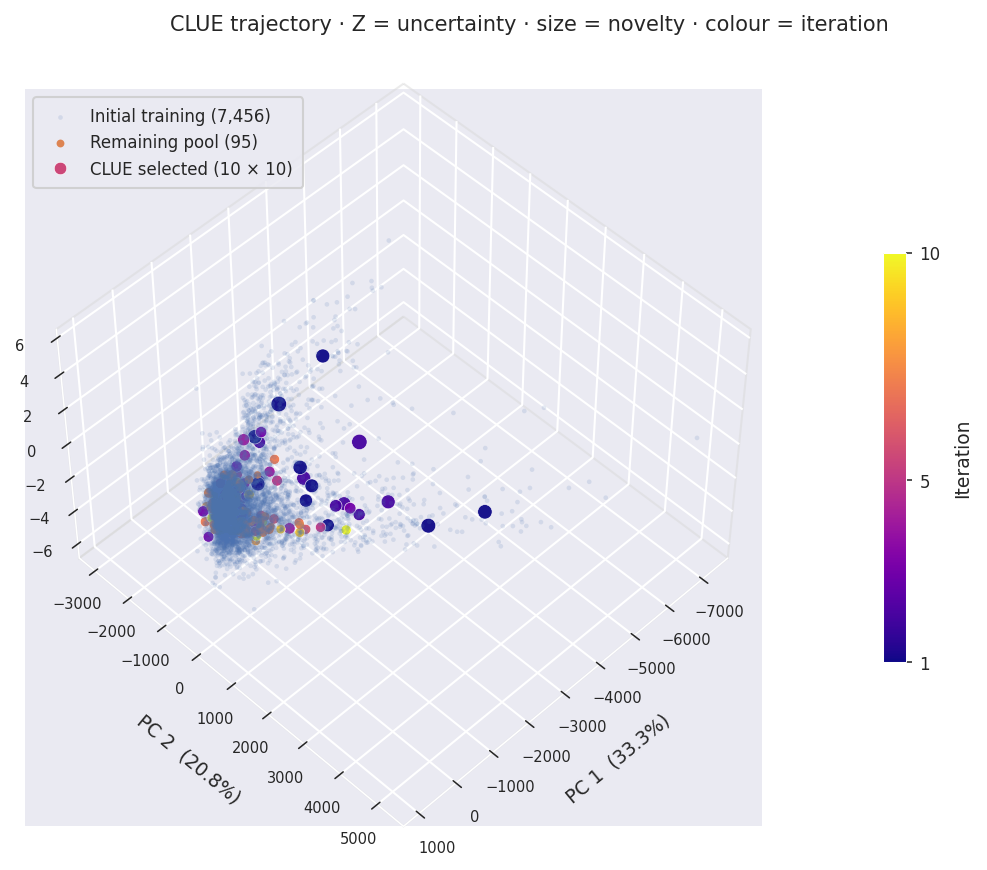

In [16]:
from mpl_toolkits.mplot3d import Axes3D   # noqa: F401
from matplotlib.lines import Line2D

# ── Viewing angle ─────────────────────────────────────────────────────────────
VIEW_ELEV = 50
VIEW_AZIM = 45

# ── Novelty → marker size ─────────────────────────────────────────────────────
nov_lo, nov_hi = novelty_all.min(), novelty_all.max()

def _nov2size(nov, s_min=2, s_max=90):
    """Map novelty score to marker area (pts²), consistent across all categories."""
    n = np.asarray(nov, dtype=float)
    return s_min + (s_max - s_min) * (n - nov_lo) / (nov_hi - nov_lo + 1e-12)

# ── Iteration colourmap (plasma) ──────────────────────────────────────────────
N_ITERS   = N_RUNS - 1
CMAP_ITER = 'plasma'
cmap_iter = mpl.colormaps[CMAP_ITER]
norm_iter = mcolors.Normalize(vmin=1, vmax=N_ITERS)

C_TRAIN  = '#4C72B0'   # steel blue  – initial training
C_TARGET = '#DD8452'   # burnt orange – remaining target pool

# ── Figure ────────────────────────────────────────────────────────────────────
fig = plt.figure(figsize=(7, 6))
ax  = fig.add_subplot(111, projection='3d')

ax.xaxis.pane.fill = False
ax.yaxis.pane.fill = False
ax.zaxis.pane.fill = False
ax.xaxis.pane.set_edgecolor('0.85')
ax.yaxis.pane.set_edgecolor('0.85')
ax.zaxis.pane.set_edgecolor('0.85')
ax.grid(True, linewidth=0.4, color='0.9')

# ── 1. Initial training data ──────────────────────────────────────────────────
mask_train = iter_assignments == 0
ax.scatter(
    coords2_ref[mask_train, 0],
    coords2_ref[mask_train, 1],
    uncert_ref[mask_train],
    c=C_TRAIN, alpha=0.15,
    s=5,
    linewidths=0,
    label=f'Initial training ({mask_train.sum():,})',
    rasterized=True,
)

# ── 2. Remaining target pool ──────────────────────────────────────────────────
ax.scatter(
    coords2_tgt[:, 0],
    coords2_tgt[:, 1],
    uncert_tgt,
    c=C_TARGET, alpha=1.0,
    s=_nov2size(novelty_tgt),
    linewidths=0,
    label=f'Remaining pool ({len(coords2_tgt):,})',
    rasterized=True,
)

# ── 3. CLUE-selected materials, coloured by iteration ────────────────────────
for it in range(1, N_ITERS + 1):
    mask = iter_assignments == it
    if not mask.any():
        continue
    ax.scatter(
        coords2_ref[mask, 0],
        coords2_ref[mask, 1],
        uncert_ref[mask],
        color=cmap_iter(norm_iter(it)),
        s=_nov2size(novelty_ref[mask]),
        alpha=0.95,
        edgecolors='white', linewidths=0.3,
        zorder=5,
    )

# ── Colorbar (iteration) ──────────────────────────────────────────────────────
sm_iter = mpl.cm.ScalarMappable(cmap=CMAP_ITER, norm=norm_iter)
sm_iter.set_array([])
cbar = fig.colorbar(sm_iter, ax=ax, shrink=0.5, aspect=18, pad=0.12)
cbar.set_label('Iteration', fontsize=9, labelpad=6)
cbar.set_ticks([1, 5, 10])
cbar.outline.set_linewidth(0.5)

# ── Proxy for promoted points in legend ───────────────────────────────────────
proxy_sel = Line2D(
    [0], [0], linestyle='none', marker='o', markersize=6,
    markerfacecolor=cmap_iter(0.5), markeredgecolor='white',
    markeredgewidth=0.3, label=f'CLUE selected (10 × {N_ITERS})',
)
handles, labels_ = ax.get_legend_handles_labels()

handles.append(proxy_sel)
ax.legend(handles=handles, loc='upper left', fontsize=8,
          framealpha=0.85, edgecolor='0.8', borderpad=0.6)

# ── Axis labels ───────────────────────────────────────────────────────────────
ax.set_xlabel(f'PC 1  ({evr2[0]:.1%})', fontsize=9, labelpad=6)
ax.set_ylabel(f'PC 2  ({evr2[1]:.1%})', fontsize=9, labelpad=6)
ax.set_zlabel('Uncertainty (run-1 model)', fontsize=9, labelpad=6)
ax.tick_params(axis='both', labelsize=7, pad=2)

ax.view_init(elev=VIEW_ELEV, azim=VIEW_AZIM)

fig.suptitle(
    'CLUE trajectory · Z = uncertainty · size = novelty · colour = iteration',
    fontsize=10, y=0.97,
)
fig.tight_layout()
plt.show()

## 8 · Save figure

In [12]:
fig.savefig('pca_uncertainty.pdf', format='pdf', dpi=300, bbox_inches='tight')
fig.savefig('pca_uncertainty.png', format='png', dpi=300, bbox_inches='tight')
print('Saved → pca_uncertainty.pdf  and  pca_uncertainty.png')

Saved → pca_uncertainty.pdf  and  pca_uncertainty.png
